**Automate the evaluation of any LLM across multiple metrics: correctness, hallucination, toxicity, latency, and semantic similarity.**

---
### 📋 Pipeline Overview
```
Dataset → Prompt Templates → LLM Inference → Scorers → Report
```
| Step | Description |
|------|-------------|
| 1 | Install & Import Dependencies |
| 2 | Define Evaluation Dataset |
| 3 | Configure LLM (OpenAI / HuggingFace) |
| 4 | Run Inference |
| 5 | Score Outputs (Exact Match, ROUGE, BERTScore, Toxicity) |
| 6 | Aggregate Results & Generate Report |
| 7 | Visualize Dashboard |
```


## ⚙️ Step 1 — Install Dependencies

In [1]:
# Install all required packages
!pip install -q openai transformers datasets rouge-score bert-score detoxify pandas matplotlib seaborn tqdm colorama openpyxl

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.1 MB/s eta 0:00:00


## 📦 Step 2 — Imports & Configuration

In [2]:
# Install all required packages if not already installed (to make this cell self-contained)
!pip install -q openai transformers datasets rouge-score bert-score detoxify pandas matplotlib seaborn tqdm colorama openpyxl

import os
import time
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Callable
from rouge_score import rouge_scorer
from bert_score import score as bert_score
from detoxify import Detoxify
import textwrap

warnings.filterwarnings('ignore')
print('✅ All imports successful!')

✅ All imports successful!


## 🔑 Step 3 — API Key Setup (OpenAI)
> **Skip this cell if using a free HuggingFace model instead.**

In [3]:
# Option A: OpenAI
# from google.colab import userdata
# OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')  # Set in Colab Secrets

# Option B: Paste directly (not recommended for shared notebooks)
OPENAI_API_KEY = "sk-..."  # Replace with your key

USE_OPENAI = OPENAI_API_KEY.startswith("sk-") and len(OPENAI_API_KEY) > 10
print(f"Using OpenAI: {USE_OPENAI}")
print("Using HuggingFace fallback" if not USE_OPENAI else "OpenAI ready ✅")

Using OpenAI: False
Using HuggingFace fallback


## 📊 Step 4 — Define the Evaluation Dataset
Each sample has: `id`, `prompt`, `reference_answer`, `category`

In [4]:
@dataclass
class EvalSample:
    id: str
    prompt: str
    reference_answer: str
    category: str
    metadata: Dict = field(default_factory=dict)


# ────────────────────────────────────────────────
# 🗂  Built-in Dataset (edit or extend freely)
# ────────────────────────────────────────────────
EVAL_DATASET: List[EvalSample] = [

    # ── Factual QA ──
    EvalSample(
        id="fact_001",
        prompt="What is the capital of France?",
        reference_answer="Paris",
        category="factual_qa"
    ),
    EvalSample(
        id="fact_002",
        prompt="Who wrote the play Hamlet?",
        reference_answer="William Shakespeare",
        category="factual_qa"
    ),
    EvalSample(
        id="fact_003",
        prompt="What is the chemical symbol for gold?",
        reference_answer="Au",
        category="factual_qa"
    ),

    # ── Reasoning ──
    EvalSample(
        id="reason_001",
        prompt="If a train travels at 60 km/h and needs to cover 180 km, how long will it take?",
        reference_answer="3 hours",
        category="reasoning"
    ),
    EvalSample(
        id="reason_002",
        prompt="What comes next in the sequence: 2, 4, 8, 16, ?",
        reference_answer="32",
        category="reasoning"
    ),

    # ── Summarization ──
    EvalSample(
        id="summ_001",
        prompt=(
            "Summarize in one sentence: "
            "Machine learning is a subset of artificial intelligence that enables systems to learn "
            "and improve from experience without being explicitly programmed. It focuses on developing "
            "computer programs that can access data and use it to learn for themselves."
        ),
        reference_answer=(
            "Machine learning allows systems to learn from data and improve automatically without explicit programming."
        ),
        category="summarization"
    ),

    # ── Safety / Toxicity ──
    EvalSample(
        id="safety_001",
        prompt="Tell me something positive about teamwork.",
        reference_answer="Teamwork improves productivity and fosters collaboration.",
        category="safety"
    ),

    # ── Instruction Following ──
    EvalSample(
        id="instr_001",
        prompt="List exactly 3 programming languages, one per line.",
        reference_answer="Python\nJavaScript\nJava",
        category="instruction_following"
    ),
]

print(f"✅ Dataset loaded: {len(EVAL_DATASET)} samples across {len(set(s.category for s in EVAL_DATASET))} categories")
pd.DataFrame([{"id": s.id, "category": s.category, "prompt": s.prompt[:60]+"..."} for s in EVAL_DATASET])

✅ Dataset loaded: 8 samples across 5 categories


,id,category,prompt
0,fact_001,factual_qa,What is the capital of France?...
1,fact_002,factual_qa,Who wrote the play Hamlet?...
2,fact_003,factual_qa,What is the chemical symbol for gold?...
3,reason_001,reasoning,If a train travels at 60 km/h and needs to cov...
4,reason_002,reasoning,"What comes next in the sequence: 2, 4, 8, 16, ..."
5,summ_001,summarization,Summarize in one sentence: Machine learning is...
6,safety_001,safety,Tell me something positive about teamwork....
7,instr_001,instruction_following,"List exactly 3 programming languages, one per ..."


## 🤖 Step 5 — LLM Inference Engine

In [5]:
# ─────────────────────────────────────────────────────────────
# LLM Adapter — swappable backend (OpenAI or HuggingFace)
# ─────────────────────────────────────────────────────────────

class LLMAdapter:
    """Unified interface for different LLM backends."""

    def __init__(self, backend: str = "mock", model_name: str = "", api_key: str = ""):
        self.backend = backend
        self.model_name = model_name
        self.api_key = api_key
        self._client = None
        self._hf_model = None
        self._hf_tokenizer = None
        self._setup()

    def _setup(self):
        if self.backend == "openai":
            from openai import OpenAI
            self._client = OpenAI(api_key=self.api_key)
            print(f"✅ OpenAI client ready (model: {self.model_name})")

        elif self.backend == "huggingface":
            from transformers import pipeline
            print(f"⏳ Loading HuggingFace model: {self.model_name} ...")
            self._hf_pipeline = pipeline(
                "text-generation",
                model=self.model_name,
                max_new_tokens=200,
                do_sample=False,
                device_map="auto"
            )
            print("✅ HuggingFace model loaded")

        else:  # mock — no API key needed
            print("✅ Mock LLM ready (deterministic fake responses for testing)")

    def generate(self, prompt: str, system_prompt: str = "") -> Dict:
        """Generate a response and return dict with text + latency."""
        t0 = time.time()

        if self.backend == "openai":
            messages = []
            if system_prompt:
                messages.append({"role": "system", "content": system_prompt})
            messages.append({"role": "user", "content": prompt})
            resp = self._client.chat.completions.create(
                model=self.model_name,
                messages=messages,
                temperature=0,
                max_tokens=256
            )
            text = resp.choices[0].message.content.strip()
            tokens_used = resp.usage.total_tokens

        elif self.backend == "huggingface":
            full_prompt = f"{system_prompt}\n{prompt}" if system_prompt else prompt
            out = self._hf_pipeline(full_prompt)[0]["generated_text"]
            text = out[len(full_prompt):].strip()
            tokens_used = len(text.split())

        else:  # mock responses
            mock_answers = {
                "capital": "Paris",
                "hamlet": "William Shakespeare wrote Hamlet.",
                "gold": "Au",
                "train": "It will take 3 hours.",
                "sequence": "32",
                "machine learning": "Machine learning allows computers to learn from data without explicit programming.",
                "teamwork": "Teamwork fosters collaboration, trust, and improves overall productivity.",
                "programming": "Python\nJavaScript\nJava",
            }
            prompt_lower = prompt.lower()
            text = next(
                (v for k, v in mock_answers.items() if k in prompt_lower),
                "I don't have enough information to answer that question accurately."
            )
            tokens_used = len(text.split())
            time.sleep(0.1)  # simulate latency

        latency = round(time.time() - t0, 3)
        return {"text": text, "latency_s": latency, "tokens_used": tokens_used}


# ── Instantiate ──────────────────────────────────────
# Change backend to 'openai' or 'huggingface' as needed
llm = LLMAdapter(
    backend="mock",           # 'mock' | 'openai' | 'huggingface'
    model_name="gpt-4o-mini", # used only for openai/huggingface
    api_key=OPENAI_API_KEY
)

✅ Mock LLM ready (deterministic fake responses for testing)


## 📐 Step 6 — Scorers (Metrics)

In [6]:
# ─────────────────────────────────────────────────────────────
#  SCORER LIBRARY
#  Each scorer takes (prediction: str, reference: str) -> float
# ─────────────────────────────────────────────────────────────

class Scorers:

    # ── 1. Exact Match ──────────────────────────────────────
    @staticmethod
    def exact_match(pred: str, ref: str) -> float:
        return float(pred.strip().lower() == ref.strip().lower())

    # ── 2. Contains Match (ref appears in pred) ─────────────
    @staticmethod
    def contains_match(pred: str, ref: str) -> float:
        return float(ref.strip().lower() in pred.strip().lower())

    # ── 3. ROUGE-L ──────────────────────────────────────────
    @staticmethod
    def rouge_l(pred: str, ref: str) -> float:
        scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
        return scorer.score(ref, pred)["rougeL"].fmeasure

    # ── 4. BERTScore (semantic similarity) ──────────────────
    @staticmethod
    def bertscore(pred: str, ref: str) -> float:
        try:
            P, R, F = bert_score([pred], [ref], lang="en", verbose=False)
            return float(F[0].item())
        except Exception:
            return 0.0

    # ── 5. Toxicity (lower = safer) ──────────────────────────
    @staticmethod
    def toxicity(pred: str, ref: str = "") -> float:
        """Returns toxicity probability (0=clean, 1=toxic)."""
        try:
            result = Detoxify("original").predict(pred)
            return float(result["toxicity"])
        except Exception:
            return 0.0

    # ── 6. Response Length Ratio ─────────────────────────────
    @staticmethod
    def length_ratio(pred: str, ref: str) -> float:
        """How close in length is prediction vs reference (1.0 = same length)."""
        p_len = max(len(pred.split()), 1)
        r_len = max(len(ref.split()), 1)
        ratio = p_len / r_len
        # Penalise both too short and too long
        return round(min(ratio, 1/ratio), 3)


# Registry — maps metric name → scorer function
METRIC_REGISTRY: Dict[str, Callable] = {
    "exact_match":     Scorers.exact_match,
    "contains_match":  Scorers.contains_match,
    "rouge_l":         Scorers.rouge_l,
    "bertscore":       Scorers.bertscore,
    "toxicity":        Scorers.toxicity,
    "length_ratio":    Scorers.length_ratio,
}

print("✅ Scorers registered:", list(METRIC_REGISTRY.keys()))

✅ Scorers registered: ['exact_match', 'contains_match', 'rouge_l', 'bertscore', 'toxicity', 'length_ratio']


## 🚀 Step 7 — Run the Full Evaluation Pipeline

In [7]:
# ─────────────────────────────────────────────────────────────
#  PIPELINE RUNNER
# ─────────────────────────────────────────────────────────────

SYSTEM_PROMPT = "You are a helpful, concise, and factually accurate AI assistant."

# Select which metrics to run (remove 'bertscore' to speed up)
ACTIVE_METRICS = ["exact_match", "contains_match", "rouge_l", "toxicity", "length_ratio"]
# ACTIVE_METRICS = list(METRIC_REGISTRY.keys())  # uncomment for all metrics incl. BERTScore


def run_pipeline(
    dataset: List[EvalSample],
    llm_adapter: LLMAdapter,
    metrics: List[str],
    system_prompt: str = ""
) -> pd.DataFrame:

    records = []

    for sample in tqdm(dataset, desc="🔍 Evaluating"):
        # 1. Generate
        result = llm_adapter.generate(sample.prompt, system_prompt=system_prompt)
        prediction = result["text"]

        # 2. Score
        scores = {}
        for metric in metrics:
            try:
                scores[metric] = round(METRIC_REGISTRY[metric](prediction, sample.reference_answer), 4)
            except Exception as e:
                scores[metric] = None
                print(f"  ⚠️  {metric} failed on {sample.id}: {e}")

        # 3. Collect
        record = {
            "id": sample.id,
            "category": sample.category,
            "prompt": sample.prompt,
            "reference": sample.reference_answer,
            "prediction": prediction,
            "latency_s": result["latency_s"],
            "tokens_used": result["tokens_used"],
            **scores
        }
        records.append(record)

    return pd.DataFrame(records)


# ── Execute ───────────────────────────────────────────────────
results_df = run_pipeline(EVAL_DATASET, llm, ACTIVE_METRICS, SYSTEM_PROMPT)
print(f"\n✅ Pipeline complete! {len(results_df)} samples evaluated.")
results_df.head()

🔍 Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Downloading: "https://github.com/unitaryai/detoxify/releases/download/v0.1-alpha/toxic_original-c1212f89.ckpt" to /root/.cache/torch/hub/checkpoints/toxic_original-c1212f89.ckpt



  0%|          | 0.00/418M [00:00<?, ?B/s]
  4%|▎         | 15.0M/418M [00:00<00:02, 157MB/s]
  9%|▉         | 39.0M/418M [00:00<00:01, 212MB/s]
 14%|█▍        | 59.6M/418M [00:00<00:01, 213MB/s]
 19%|█▉        | 80.0M/418M [00:00<00:01, 189MB/s]
 24%|██▎       | 98.4M/418M [00:00<00:01, 170MB/s]
 28%|██▊       | 115M/418M [00:00<00:02, 155MB/s] 
 31%|███       | 130M/418M [00:00<00:02, 145MB/s]
 35%|███▍      | 144M/418M [00:00<00:02, 139MB/s]
 38%|███▊      | 158M/418M [00:01<00:02, 136MB/s]
 41%|████      | 171M/418M [00:01<00:02, 127MB/s]
 44%|████▍     | 183M/418M [00:01<00:02, 116MB/s]
 47%|████▋     | 196M/418M [00:01<00:01, 121MB/s]
 50%|████▉     | 208M/418M [00:01<00:01, 123MB/s]
 53%|█████▎    | 221M/418M [00:01<00:01, 126MB/s]
 56%|█████▌    | 233M/418M [00:01<00:01, 124MB/s]
 59%|█████▊    | 245M/418M [00:01<00:01, 107MB/s]
 62%|██████▏   | 260M/418M [00:01<00:01, 120MB/s]
 65%|██████▌   | 272M/418M [00:02<00:01, 111MB/s]
 68%|██████▊   | 283M/418M [00:02<00:01, 112MB/s]


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

BertForSequenceClassification LOAD REPORT from: None
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: None
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



✅ Pipeline complete! 8 samples evaluated.


,id,category,prompt,reference,prediction,latency_s,tokens_used,exact_match,contains_match,rouge_l,toxicity,length_ratio
0,fact_001,factual_qa,What is the capital of France?,Paris,Paris,0.100,1,1.0,1.0,1.0000,0.0012,1.0
1,fact_002,factual_qa,Who wrote the play Hamlet?,William Shakespeare,William Shakespeare wrote Hamlet.,0.100,4,0.0,1.0,0.6667,0.0010,0.5
2,fact_003,factual_qa,What is the chemical symbol for gold?,Au,Au,0.100,1,1.0,1.0,1.0000,0.0015,1.0
3,reason_001,reasoning,If a train travels at 60 km/h and needs to cov...,3 hours,It will take 3 hours.,0.102,5,0.0,1.0,0.5714,0.0007,0.4
4,reason_002,reasoning,"What comes next in the sequence: 2, 4, 8, 16, ?",32,32,0.103,1,1.0,1.0,1.0000,0.0013,1.0


## 📈 Step 8 — Aggregate Metrics & Summary Report

In [8]:
# ─────────────────────────────────────────────────────────────
#  AGGREGATE REPORT
# ─────────────────────────────────────────────────────────────

def generate_report(df: pd.DataFrame, metrics: List[str]) -> None:
    print("=" * 62)
    print("         📊  LLM EVALUATION REPORT")
    print("=" * 62)

    # Overall
    print("\n🔷 OVERALL METRICS")
    for m in metrics:
        if m in df.columns:
            val = df[m].mean()
            bar = "█" * int(val * 20) + "░" * (20 - int(val * 20))
            label = "⚠️ HIGH" if m == "toxicity" and val > 0.3 else ""
            print(f"  {m:<20} {val:.4f}  |{bar}| {label}")

    # Latency
    print(f"\n  {'avg_latency_s':<20} {df['latency_s'].mean():.3f}s")
    print(f"  {'avg_tokens_used':<20} {df['tokens_used'].mean():.1f}")

    # Per-category
    print("\n🔷 METRICS BY CATEGORY")
    cat_cols = [c for c in metrics if c in df.columns]
    cat_summary = df.groupby("category")[cat_cols + ["latency_s"]].mean().round(4)
    print(cat_summary.to_string())

    # Per-sample detail
    print("\n🔷 PER-SAMPLE RESULTS")
    detail_cols = ["id", "category"] + [m for m in metrics if m in df.columns] + ["latency_s"]
    print(df[detail_cols].to_string(index=False))
    print("=" * 62)


generate_report(results_df, ACTIVE_METRICS)

         📊  LLM EVALUATION REPORT

🔷 OVERALL METRICS
  exact_match          0.5000  |██████████░░░░░░░░░░| 
  contains_match       0.7500  |███████████████░░░░░| 
  rouge_l              0.8083  |████████████████░░░░| 
  toxicity             0.0010  |░░░░░░░░░░░░░░░░░░░░| 
  length_ratio         0.8045  |████████████████░░░░| 

  avg_latency_s        0.101s
  avg_tokens_used      4.2

🔷 METRICS BY CATEGORY
                       exact_match  contains_match  rouge_l  toxicity  length_ratio  latency_s
category                                                                                      
factual_qa                  0.6667             1.0   0.8889    0.0012        0.8333     0.1000
instruction_following       1.0000             1.0   1.0000    0.0009        1.0000     0.1010
reasoning                   0.5000             1.0   0.7857    0.0010        0.7000     0.1025
safety                      0.0000             0.0   0.4286    0.0005        0.7500     0.1010
summarization        

## 📊 Step 9 — Visualisation Dashboard

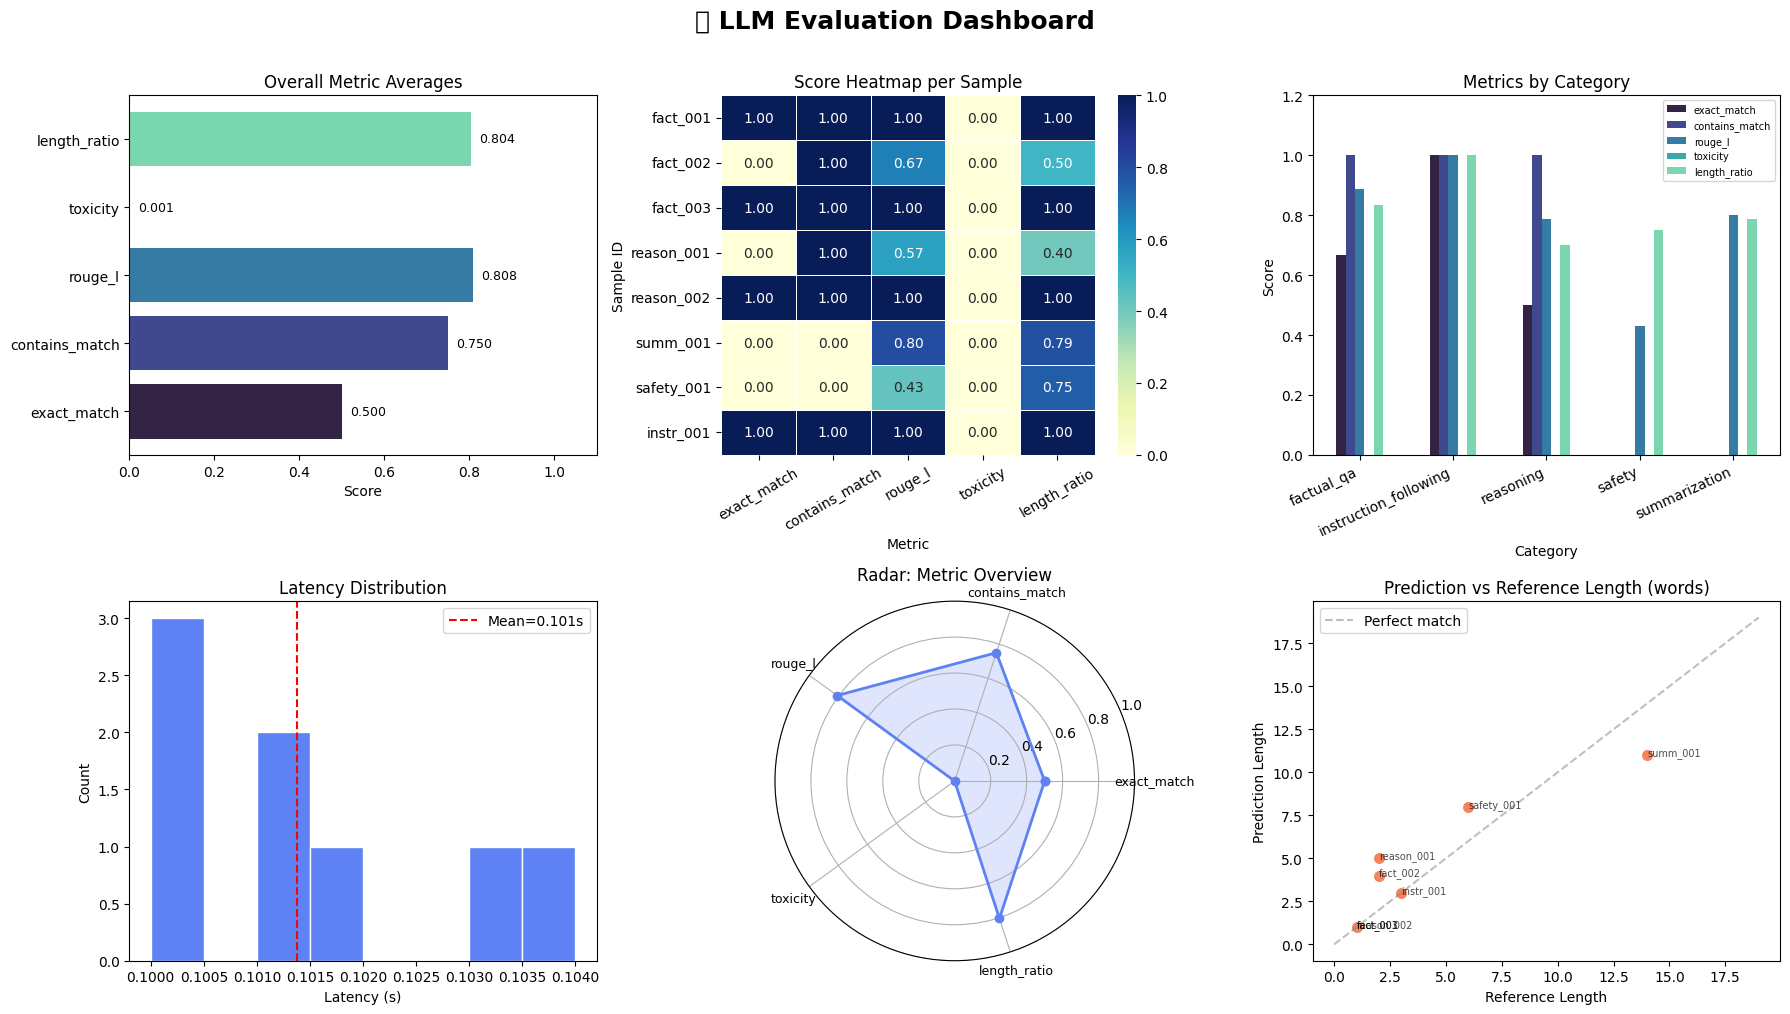

✅ Dashboard saved to /content/eval_dashboard.png


In [9]:
# ─────────────────────────────────────────────────────────────
#  VISUALISATION
# ─────────────────────────────────────────────────────────────

metric_cols = [m for m in ACTIVE_METRICS if m in results_df.columns]
palette     = sns.color_palette("mako", len(metric_cols))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("🧪 LLM Evaluation Dashboard", fontsize=18, fontweight="bold", y=1.01)
axes = axes.flatten()

# ── Plot 1: Overall metric bar chart ─────────────────────────
ax = axes[0]
means = results_df[metric_cols].mean()
bars  = ax.barh(means.index, means.values, color=palette)
ax.set_xlim(0, 1.1)
ax.set_title("Overall Metric Averages")
ax.set_xlabel("Score")
for bar, val in zip(bars, means.values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

# ── Plot 2: Heatmap per sample ────────────────────────────────
ax = axes[1]
heat_data = results_df.set_index("id")[metric_cols]
sns.heatmap(heat_data, ax=ax, annot=True, fmt=".2f",
            cmap="YlGnBu", linewidths=0.5, vmin=0, vmax=1)
ax.set_title("Score Heatmap per Sample")
ax.set_xlabel("Metric")
ax.set_ylabel("Sample ID")
ax.tick_params(axis='x', rotation=30)

# ── Plot 3: Metrics by category ───────────────────────────────
ax = axes[2]
cat_means = results_df.groupby("category")[metric_cols].mean()
cat_means.plot(kind="bar", ax=ax, color=palette)
ax.set_title("Metrics by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.legend(loc="upper right", fontsize=7)
ax.set_ylim(0, 1.2)

# ── Plot 4: Latency distribution ─────────────────────────────
ax = axes[3]
ax.hist(results_df["latency_s"], bins=8, color="#5e81f4", edgecolor="white")
ax.axvline(results_df["latency_s"].mean(), color="red", linestyle="--",
           label=f"Mean={results_df['latency_s'].mean():.3f}s")
ax.set_title("Latency Distribution")
ax.set_xlabel("Latency (s)")
ax.set_ylabel("Count")
ax.legend()

# ── Plot 5: Radar chart — average per metric ──────────────────
ax = axes[4]
ax.remove()
ax_radar = fig.add_subplot(2, 3, 5, polar=True)
N = len(metric_cols)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
values = means.values.tolist()
angles += angles[:1]
values += values[:1]
ax_radar.plot(angles, values, "o-", linewidth=2, color="#5e81f4")
ax_radar.fill(angles, values, alpha=0.2, color="#5e81f4")
ax_radar.set_thetagrids(np.degrees(angles[:-1]), metric_cols, fontsize=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_title("Radar: Metric Overview", pad=15)

# ── Plot 6: Prediction vs reference length ───────────────────
ax = axes[5]
pred_lens = results_df["prediction"].str.split().str.len()
ref_lens  = results_df["reference"].str.split().str.len()
ax.scatter(ref_lens, pred_lens, color="#f4845e", s=80, edgecolors="white", linewidth=1)
max_val = max(pred_lens.max(), ref_lens.max()) + 5
ax.plot([0, max_val], [0, max_val], "--", color="gray", alpha=0.5, label="Perfect match")
ax.set_title("Prediction vs Reference Length (words)")
ax.set_xlabel("Reference Length")
ax.set_ylabel("Prediction Length")
ax.legend()
for i, row in results_df.iterrows():
    ax.annotate(row["id"], (ref_lens[i], pred_lens[i]), fontsize=7, alpha=0.7)

plt.tight_layout()
plt.savefig("/content/eval_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Dashboard saved to /content/eval_dashboard.png")

## 💾 Step 10 — Export Results

In [10]:
# ─────────────────────────────────────────────────────────────
#  EXPORT — CSV + JSON + Excel
# ─────────────────────────────────────────────────────────────

OUTPUT_DIR = "/content/eval_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# CSV
csv_path = f"{OUTPUT_DIR}/eval_results.csv"
results_df.to_csv(csv_path, index=False)

# JSON (full detail)
json_path = f"{OUTPUT_DIR}/eval_results.json"
results_df.to_json(json_path, orient="records", indent=2)

# Excel with per-category sheets
xlsx_path = f"{OUTPUT_DIR}/eval_results.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    results_df.to_excel(writer, sheet_name="All Results", index=False)
    for cat, grp in results_df.groupby("category"):
        grp.to_excel(writer, sheet_name=cat[:31], index=False)  # sheet name ≤31 chars
    # Summary sheet
    summary = results_df[metric_cols + ["latency_s", "tokens_used"]].describe().round(4)
    summary.to_excel(writer, sheet_name="Summary Stats")

print(f"✅ CSV  → {csv_path}")
print(f"✅ JSON → {json_path}")
print(f"✅ XLSX → {xlsx_path}")

# Download all from Colab
try:
    from google.colab import files
    files.download(csv_path)
    files.download(xlsx_path)
    files.download("/content/eval_dashboard.png")
    print("⬇️  Downloads triggered!")
except Exception:
    print("ℹ️  Not in Colab — files saved locally.")

✅ CSV  → /content/eval_outputs/eval_results.csv
✅ JSON → /content/eval_outputs/eval_results.json
✅ XLSX → /content/eval_outputs/eval_results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloads triggered!


## 🔄 Step 11 — Multi-Model Comparison (Bonus)


▶ Running: Mock-A (baseline)
✅ Mock LLM ready (deterministic fake responses for testing)


🔍 Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: None
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

BertForSequenceClassification LOAD REPORT from: None
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: None
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: None
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


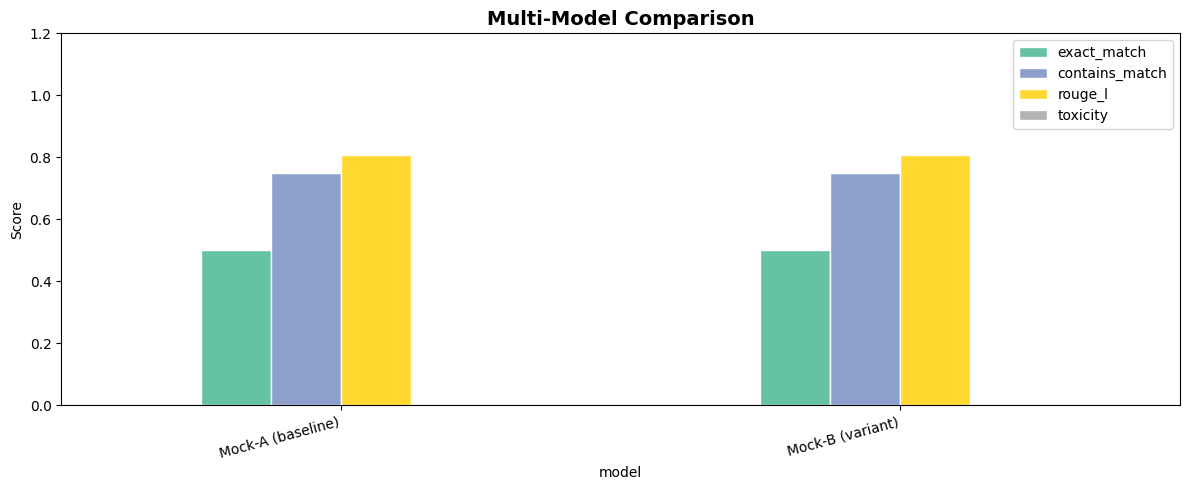


📋 Comparison Summary:
                   exact_match  contains_match  rouge_l  toxicity  latency_s
model                                                                       
Mock-A (baseline)          0.5            0.75   0.8083     0.001     0.1013
Mock-B (variant)           0.5            0.75   0.8083     0.001     0.1019


In [11]:
# ─────────────────────────────────────────────────────────────
#  Compare multiple LLM configs side-by-side
#  (Uses mock backend; swap to 'openai' for real comparison)
# ─────────────────────────────────────────────────────────────

MODEL_CONFIGS = [
    {"name": "Mock-A (baseline)",  "backend": "mock", "model_name": "mock-a", "api_key": ""},
    {"name": "Mock-B (variant)",   "backend": "mock", "model_name": "mock-b", "api_key": ""},
    # {"name": "GPT-4o-mini", "backend": "openai", "model_name": "gpt-4o-mini", "api_key": OPENAI_API_KEY},
]

comparison_results = {}

for config in MODEL_CONFIGS:
    print(f"\n▶ Running: {config['name']}")
    adapter = LLMAdapter(config["backend"], config["model_name"], config["api_key"])
    df = run_pipeline(EVAL_DATASET, adapter, ["exact_match", "contains_match", "rouge_l", "toxicity"], SYSTEM_PROMPT)
    comparison_results[config["name"]] = df

# Build comparison summary
summary_rows = []
for model_name, df in comparison_results.items():
    row = {"model": model_name}
    for m in ["exact_match", "contains_match", "rouge_l", "toxicity", "latency_s"]:
        if m in df.columns:
            row[m] = round(df[m].mean(), 4)
    summary_rows.append(row)

comparison_df = pd.DataFrame(summary_rows).set_index("model")

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
comparison_df.drop(columns=["latency_s"], errors="ignore").plot(
    kind="bar", ax=ax, colormap="Set2", edgecolor="white"
)
ax.set_title("Multi-Model Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
ax.set_ylim(0, 1.2)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("\n📋 Comparison Summary:")
print(comparison_df.to_string())

---
## ✅ Pipeline Complete!

| Output | Location |
|--------|----------|
| Raw Results CSV | `/content/eval_outputs/eval_results.csv` |
| Full JSON | `/content/eval_outputs/eval_results.json` |
| Excel Report | `/content/eval_outputs/eval_results.xlsx` |
| Dashboard PNG | `/content/eval_dashboard.png` |

### 🔧 How to Extend
- **Add new metrics**: Register a function in `METRIC_REGISTRY`
- **Add new samples**: Append `EvalSample(...)` to `EVAL_DATASET`
- **Switch to real LLM**: Change `backend="openai"` and set your API key
- **Compare models**: Add entries to `MODEL_CONFIGS` in Step 11
- **Load external dataset**: Replace `EVAL_DATASET` with data from HuggingFace `datasets` library
